Para Verificar Performance da GPU Usar o Comando:

watch -n 1 amd-smi

## Modo do Script:

TRAIN: o modelo será treinado e o melhor registrado será salvo.

TEST: o modelo salvo será testado com o dataset de teste

BOTH: o modelo sera treinado, salvo e testado

# Setup do Projeto

In [1]:
import torch
from config import *

# Setup Agnostic Code for GPU/CPU
if torch.cuda.is_available():
    device = 'cuda'
    print(f"CUDA está disponivel!\nDispositivo configurado para: {device}\nDevice count: {torch.cuda.device_count()}\nNome do dispositivo: {torch.cuda.get_device_name(0)}\nVersao do PyTorch: {torch.__version__}")
else:
    device = 'cpu'
    print(f"CUDA não está disponível.\nDispositivo configurado para: {device}\nVersao do PyTorch: {torch.__version__}")

CUDA está disponivel!
Dispositivo configurado para: cuda
Device count: 1
Nome do dispositivo: AMD Radeon RX 7800 XT
Versao do PyTorch: 2.8.0+rocm7.2.0.gitbf943426


In [2]:
# Bibliotecas e imports
import custom_cityscapes as ccs
import custom_transforms as ctr
import custom_metrics as cmt
import models.FastSCNN as fscnn
import train_model as tr
import eval_model as ev
from utils import *

from torchvision import datasets
from torch.utils.data import DataLoader
from torchinfo import summary
from torch import optim
from kornia import losses
# Mais informacoes em https://lightning.ai/docs/torchmetrics/stable/classification/jaccard_index.html#torchmetrics.classification.MulticlassJaccardIndex
from torchmetrics.classification import MulticlassJaccardIndex # Jaccard Index eh a mesma coisa que IoU (Intersection over Union) e esse opjeto pode calcular tambem iIoU
from pathlib import Path
import json

/home/jose-vitor/Documents/pytorch_projects/Fast-SCNN/QFast-SCNN_with_Brevitas_and_FINN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preparando o Dataset Cityscapes

In [3]:
ds_lables = ccs.CityscapesLables()

# Criando o colormap para as classes
cmap = ds_lables.get_cmap()

# Imprimindo informacoes relevantes
print(f"O dataset possui {len(ds_lables.id_names)} classes treinaveis:")
ds_lables.id_names

O dataset possui 20 classes treinaveis:


{0: 'road',
 1: 'sidewalk',
 2: 'building',
 3: 'wall',
 4: 'fence',
 5: 'pole',
 6: 'traffic light',
 7: 'traffic sign',
 8: 'vegetation',
 9: 'terrain',
 10: 'sky',
 11: 'person',
 12: 'rider',
 13: 'car',
 14: 'truck',
 15: 'bus',
 16: 'train',
 17: 'motorcycle',
 18: 'bicycle',
 255: 'ignore'}

# Importar o Dataset Cityscapes

Definir Funções de Transform

In [4]:
custom_trans = ctr.Transforms(conv_size=(IM_HEIGHT, IM_WIDTH),
                              lable_conversion=ds_lables.lable_conversion)

Importar Dataset

In [5]:
train_dataset = ccs.AugmentedCityscapes(DATA_PATH,
                             split = 'train',
                             mode='fine',
                             target_type='semantic',
                             transform=custom_trans.train_transform,
                             target_transform=custom_trans.target_transform,
                             data_augmentation=custom_trans.data_augmentation,
                             post_data_augmentation=custom_trans.post_data_augmentation)
val_dataset = datasets.Cityscapes(DATA_PATH,
                           split = 'val',
                           mode='fine',
                           target_type='semantic',
                           transform=custom_trans.val_transform,
                           target_transform=custom_trans.target_transform)
test_dataset = datasets.Cityscapes(DATA_PATH,
                            split = 'test',
                            mode='fine',
                            target_type='semantic',
                            transform=custom_trans.val_transform)

In [6]:
# Imprimir informacoes importantes dos datasets
img, smnt = train_dataset[0]
print(f"O Dataset de treino possui {len(train_dataset)} amostras.\n"
      f"O Dataset de validação possui {len(val_dataset)} amostras.\n"
      f"O Dataset de teste possui {len(test_dataset)} amostras.\n"
      f"Cada imagem posssui tamanho {img.shape} e tipo {img.dtype}, e cada mascara possui tamanho {smnt.shape} e tipo {smnt.dtype}.\n")

#print(f"Primeira Imagem do dataset de treino:\n{img}\nPrimenra mascara do dataset de treino:\n{smnt}")

O Dataset de treino possui 2975 amostras.
O Dataset de validação possui 500 amostras.
O Dataset de teste possui 1525 amostras.
Cada imagem posssui tamanho torch.Size([3, 768, 768]) e tipo torch.float32, e cada mascara possui tamanho torch.Size([768, 768]) e tipo torch.uint8.



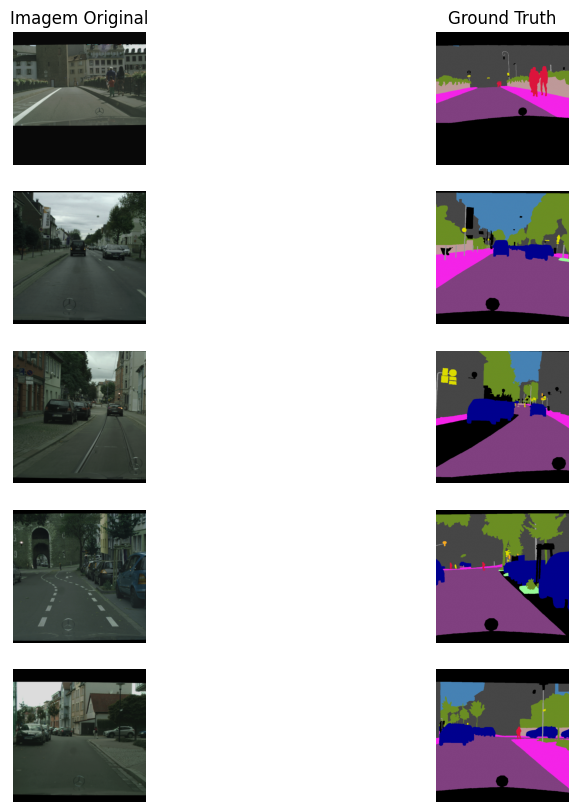

In [7]:
# Testando a funcao de exibicao
dataset_show(train_dataset, n=5, cmap=cmap)

In [8]:
# Gerar lista com pesos para as classes a partir do histograma de frequencia das classes no dataset

# Define e cria pasta para salvar pesos e histogramas
save_path = "./classes_weights"

# Metodo para calcular os pesos das classes, pode ser 'enet', 'median_freq_balancing' ou 'logarithmic'
method = 'enet'

# Define o caminho do arquivo onde os pesos das classes serao salvos, e cria a pasta caso ela nao exista
save_path = Path(save_path / Path(f'class_weights_{method}.json'))

if GENERATE_HISTOGRAM:

    # Criar um dataset sem data augmentation para calcular o histograma de frequencia das classes no dataset, e consequentemente os pesos das classes
    histogram_dataset = datasets.Cityscapes(DATA_PATH,
                                            split = 'train',
                                            mode='fine',
                                            target_type='semantic',
                                            transform=custom_trans.val_transform,
                                            target_transform=custom_trans.target_transform)
    
    # Criar um dataloader para o dataset de histograma, sem shuffle, para calcular o histograma de frequencia das classes no dataset
    histogram_dataloader = DataLoader(histogram_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
    
    # Chama a funcao para calcular os pesos e o histograma, e os salva na pasta definida
    class_weights = ds_lables.get_weights(histogram_dataloader, method=method, print_histogram=True, save_path=save_path, device=device)

    print(f"Pesos das classes calculados e salvos no arquivo {save_path}:\n{class_weights}")

else:
    # pega os pesos das classes calculados anteriormente
    with open(save_path, "r") as f:
        class_weights = torch.tensor(list(json.load(f).values())).to(device) # Carrega os pesos das classes do arquivo salvo anteriormente e converte para tensor
        print(f"Pesos das classes carregados do arquivo {save_path}:\n{class_weights}")

Pesos das classes carregados do arquivo classes_weights/class_weights_enet.json:
tensor([ 3.3632, 14.0408,  4.9860, 39.2617, 36.5217, 32.8974, 46.2848, 40.6889,
         6.6957, 33.5658, 18.4602, 32.9789, 47.6775, 12.7070, 45.2076, 45.7850,
        45.8268, 48.4075, 42.7600], device='cuda:0')


Criar dataloaders

In [9]:
# Criando datalaoders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=True, pin_memory=True)

In [10]:
# Imprimindo informacoes relevantes dos dataloaders
train_features_batch, train_labels_batch = next(iter(train_dataloader))
val_features_batch, val_labels_batch = next(iter(val_dataloader))
print(f"O pacote de imagens para treino possui tamanho: {train_features_batch.size()}, e o tamanho do pacote da mascaras para treino possui tamanho: {train_labels_batch.size()}")
print(f"O pacote de imagens para validacao possui tamanho: {val_features_batch.size()}, e o tamanho do pacote da mascaras para validacao possui tamanho: {val_labels_batch.size()}")

O pacote de imagens para treino possui tamanho: torch.Size([12, 3, 768, 768]), e o tamanho do pacote da mascaras para treino possui tamanho: torch.Size([12, 768, 768])
O pacote de imagens para validacao possui tamanho: torch.Size([12, 3, 1024, 2048]), e o tamanho do pacote da mascaras para validacao possui tamanho: torch.Size([12, 1024, 2048])


## Criar Modelo 

In [11]:
# -- IMPORTANDO OS PESO DO MODELO ORIGINAL PARA O PROJETO --

if Path("./model_weights/og_params/fast_scnn_citys.pth").is_file():
    print("Os pesos originais do modelo ja foram baixados anteriormente, pulando download.")
else:
    !git clone https://github.com/Tramac/Fast-SCNN-pytorch.git # clona repositorio com modelo e pesos originais do Fast-SCNN
    !cp ./Fast-SCNN-pytorch/weights/fast_scnn_citys.pth ./model_weights/og_params/fast_scnn_citys.pth # copia os pesos originais do modelo para a pasta do projeto
    !rm -rf ./Fast-SCNN-pytorch # remove o repositorio clonado para economizar espaco

Os pesos originais do modelo ja foram baixados anteriormente, pulando download.


In [12]:
# CRIANDO O MODELO
model = fscnn.FastSCNN(num_classes=NUM_CLASSES, aux=False).to(device)
model = load_state_dict(model, path="./model_weights/og_params/fast_scnn_citys.pth")


# Evita erro de memória no torchinfo com resolução alta
model.eval()
summary(model,
        input_size=(1, 3, IM_HEIGHT, IM_WIDTH),
        device=device,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]) # especificando para mostrar os nomes das variaveis, o que ajuda a entender melhor a arquitetura do modelo e a quantidade de parametros treinaveis em cada camada.

Carregando modelo fast_scnn_citys


Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
FastSCNN (FastSCNN)                                     [1, 3, 1024, 2048]   [1, 19, 1024, 2048]  --                   True
├─LearningToDownsample (learning_to_downsample)         [1, 3, 1024, 2048]   [1, 64, 128, 256]    --                   True
│    └─_ConvBNReLU (conv)                               [1, 3, 1024, 2048]   [1, 32, 511, 1023]   --                   True
│    │    └─Sequential (conv)                           [1, 3, 1024, 2048]   [1, 32, 511, 1023]   928                  True
│    └─_DSConv (dsconv1)                                [1, 32, 511, 1023]   [1, 48, 256, 512]    --                   True
│    │    └─Sequential (conv)                           [1, 32, 511, 1023]   [1, 48, 256, 512]    1,984                True
│    └─_DSConv (dsconv2)                                [1, 48, 256, 512]    [1, 64, 128, 256]    --                   True
│  

In [13]:
# Testar entradas e saidas do Modelo com uma imagem do dataset
test_input = train_dataset[0][0].unsqueeze(0).to(device) # Adiciona uma dimensão de batch e move para o dispositivo
test_output = model(test_input)
test_output_softmax = torch.softmax(test_output, dim=1).argmax(dim=1)
print(f"Tamanho da entrada: {test_input.shape}\n"
      f"Tamanho da saida: {test_output.shape}\n"
      f"Tamanho da saida com softmax: {test_output_softmax.shape}")
test_output_softmax

Tamanho da entrada: torch.Size([1, 3, 768, 768])
Tamanho da saida: torch.Size([1, 19, 768, 768])
Tamanho da saida com softmax: torch.Size([1, 768, 768])


tensor([[[2, 2, 2,  ..., 2, 2, 2],
         [2, 2, 2,  ..., 2, 2, 2],
         [2, 2, 2,  ..., 2, 2, 2],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0')

## Treinar Modelo E MOSTRAR RESULTADOS

In [14]:
# Definir loss, optim e metricas

# Separa em dois grupos de parametros para aplicar diferentes decaimentos de pesos (L2 regularization), conforme mencionado no artigo original do Fast-SCNN
depthwise_params = []
non_depthwise_params = []
for name, param in model.named_parameters():
    # procura por convolucoes depthwise, que possuem kernel com 1 canal de entrada. Ex: [32, 1, 3, 3] (32 kernels de dimencao 3x3, um para cada canal)
    if param.requires_grad:
        if len(param.shape) == 4 and param.shape[1] == 1:
            depthwise_params.append(param)
        else:
            non_depthwise_params.append(param)

focal_loss = losses.FocalLoss(alpha=0.25, gamma=1.0, reduction='mean', weight=class_weights, ignore_index=255).to(device) # Focal Loss com pesos para lidar melhor com o desbalanceamento de classes
focal_tvensky_loss = cmt.FocalTverskyLoss(alpha=0.7, beta=0.3, gamma=1.33, eps=1e-8, ignore_index=255).to(device) # Perda baseada em regiao, baseado em IoU, no entando com pesos para falsos positivos e falsos negativos, alem de correcao focal.
loss_fn = lambda outputs, targets: focal_loss(outputs, targets) + focal_tvensky_loss(outputs, targets) # Combinacao das duas loss functions para aproveitar os beneficios de ambas

optim_fn = optim.AdamW([
    {'params': depthwise_params, 'weight_decay': 0.0},
    {'params': non_depthwise_params, 'weight_decay': 4e-5}
], lr=LEARNING_RATE) # Otimizador com grupos de parametros para aplicar taxas de aprendizado diferentes no encoder e decoder

IoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=255, average='none').to(device)
mIoU_metric = MulticlassJaccardIndex(num_classes=NUM_CLASSES, ignore_index=255, average='macro').to(device)
metrics = {'IoU': IoU_metric, 'mIoU': mIoU_metric} # Dicionário de metricas para facilitar o monitoramento durante o treinamento e validacao

# Escolha da metrica que sera avaliada para salvar o melhor modelo, pode ser 'loss' ou o nome de alguma metrica definida no dicionario de metricas, como 'IoU' ou 'mIoU'
val_to_monitor = 'mIoU'

Testes de Sanidade

Antes de trainar o modelo, vamos vverificar a sua performance com os pesoss pré-treinados

In [15]:
# Testar Parametros
sanity_check = ev.EvalModel(model=model, device=device)
sanity_metrics = sanity_check.eval(val_dataloader, metrics, loss_fn)

100%|██████████| 42/42 [00:21<00:00,  1.96it/s]

Eval Results: Loss - 0.1080 | mIoU - 0.5484 | 


In [16]:
sanity_metrics

[tensor([0.9576, 0.6991, 0.8663, 0.3183, 0.3996, 0.3624, 0.3433, 0.5112, 0.8840,
         0.5250, 0.9149, 0.6188, 0.2444, 0.8743, 0.4288, 0.4367, 0.2747, 0.1789,
         0.5810]),
 tensor(0.5484)]

In [17]:
# Treinar o modelo
#%env TORCH_USE_HIP_DSA=1
if SCRIPT_MODE != "TEST":
    model = torch.compile(model) # Compila o modelo para melhorar a performance.
    fit_model = tr.TrainModel(model, loss_fn, optim_fn, metrics,
                                val_to_monitor=val_to_monitor,
                                scheduler_name="ReduceLROnPlateau", # Scheduler para reduzir a taxa de aprendizado quando a metrica monitorada parar de melhorar, o que ajuda a escapar de platos e melhorar a convergencia.
                                max_lr = 1e-3, # valido apenas para o OneCycleLR, e ignorado caso scheduler_fn seja diferente de "OneCycleLR"
                                epochs=EPOCHS,
                                device=device)
    
    fit_model(train_dataloader, val_dataloader)

Melhor valor da metrica monitorada (mIoU) registrado no modelo salvo: 0.5457

EPOCH 1/10


100%|██████████| 248/248 [02:40<00:00,  1.54it/s]


train_loss: 0.1020 | train_mIoU: 0.5384 | val_loss: 0.1002 | val_mIoU: 0.5426 | 

EPOCH 2/10


100%|██████████| 248/248 [02:30<00:00,  1.65it/s]


train_loss: 0.0975 | train_mIoU: 0.5394 | val_loss: 0.1004 | val_mIoU: 0.5422 | 

EPOCH 3/10


...

train_loss: 0.0892 | train_mIoU: 0.5488 | val_loss: 0.1018 | val_mIoU: 0.5491 | 

EPOCH 9/10


100%|██████████| 248/248 [02:35<00:00,  1.60it/s]


train_loss: 0.0888 | train_mIoU: 0.5501 | val_loss: 0.0977 | val_mIoU: 0.5505 | 

EPOCH 10/10


100%|██████████| 248/248 [02:28<00:00,  1.67it/s]


train_loss: 0.0877 | train_mIoU: 0.5509 | val_loss: 0.0985 | val_mIoU: 0.5513 | 

Treino do modelo foi finalizado!
O modelo com melhor mIoU foi registrado no Epoch 10.
Esse modelo foi salvo no caminho ./model_weights/new_params/best_model.pth


## TESTAR MODELO SALVO

Carregando modelo best_model
Carregando resultados do modelo best_model_results


<Figure size 500x500 with 0 Axes>

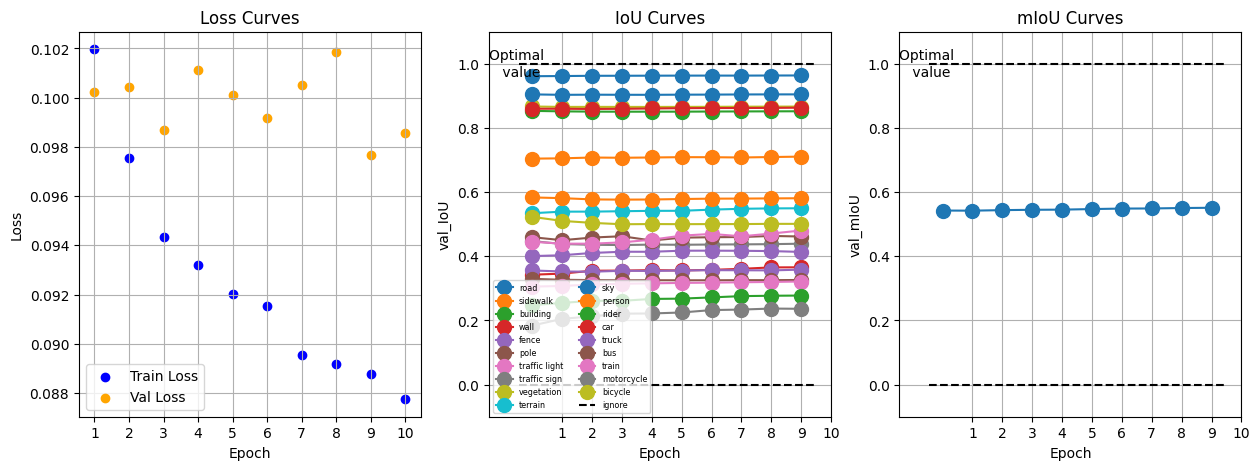

In [18]:
if SCRIPT_MODE != "TRAIN":

    # Criando novo modelo para carregar o salvo
    loaded_model = fscnn.FastSCNN(num_classes=NUM_CLASSES, aux=False).to(device)

    # Carregando apenas os parametros (state_dict()), pois isso flexibiliza o modelo e evita erros de incompatibilidade com parametros e caminhos do modelo original
    eval_fastscnn = ev.EvalModel(model = loaded_model,
                                 state_dict_path="./model_weights/new_params/best_model.pth",
                                 results_path="./model_weights/new_params/best_model_results.pt",
                                 device=device)
    
    # Imprimir os resultados
    print_results(eval_fastscnn.train_results, metrics)
    best_loaded_results = eval_fastscnn.get_best_results(IoU_lables=ds_lables.id_names)

In [19]:
best_loaded_results

{'val_loss': 0.09854798994603611,
 'val_IoU': {'road': 0.9636823534965515,
  'sidewalk': 0.7107264995574951,
  'building': 0.8520631194114685,
  'wall': 0.3657115697860718,
  'fence': 0.3585008680820465,
  'pole': 0.3262161910533905,
  'traffic light': 0.3214288055896759,
  'traffic sign': 0.4392859637737274,
  'vegetation': 0.8667042851448059,
  'terrain': 0.5496996641159058,
  'sky': 0.9047002196311951,
  'person': 0.5809829235076904,
  'rider': 0.27767789363861084,
  'car': 0.8632018566131592,
  'truck': 0.41363850235939026,
  'bus': 0.4616817533969879,
  'train': 0.48042595386505127,
  'motorcycle': 0.23633261024951935,
  'bicycle': 0.5010976195335388},
 'val_mIoU': 0.5512504577636719}

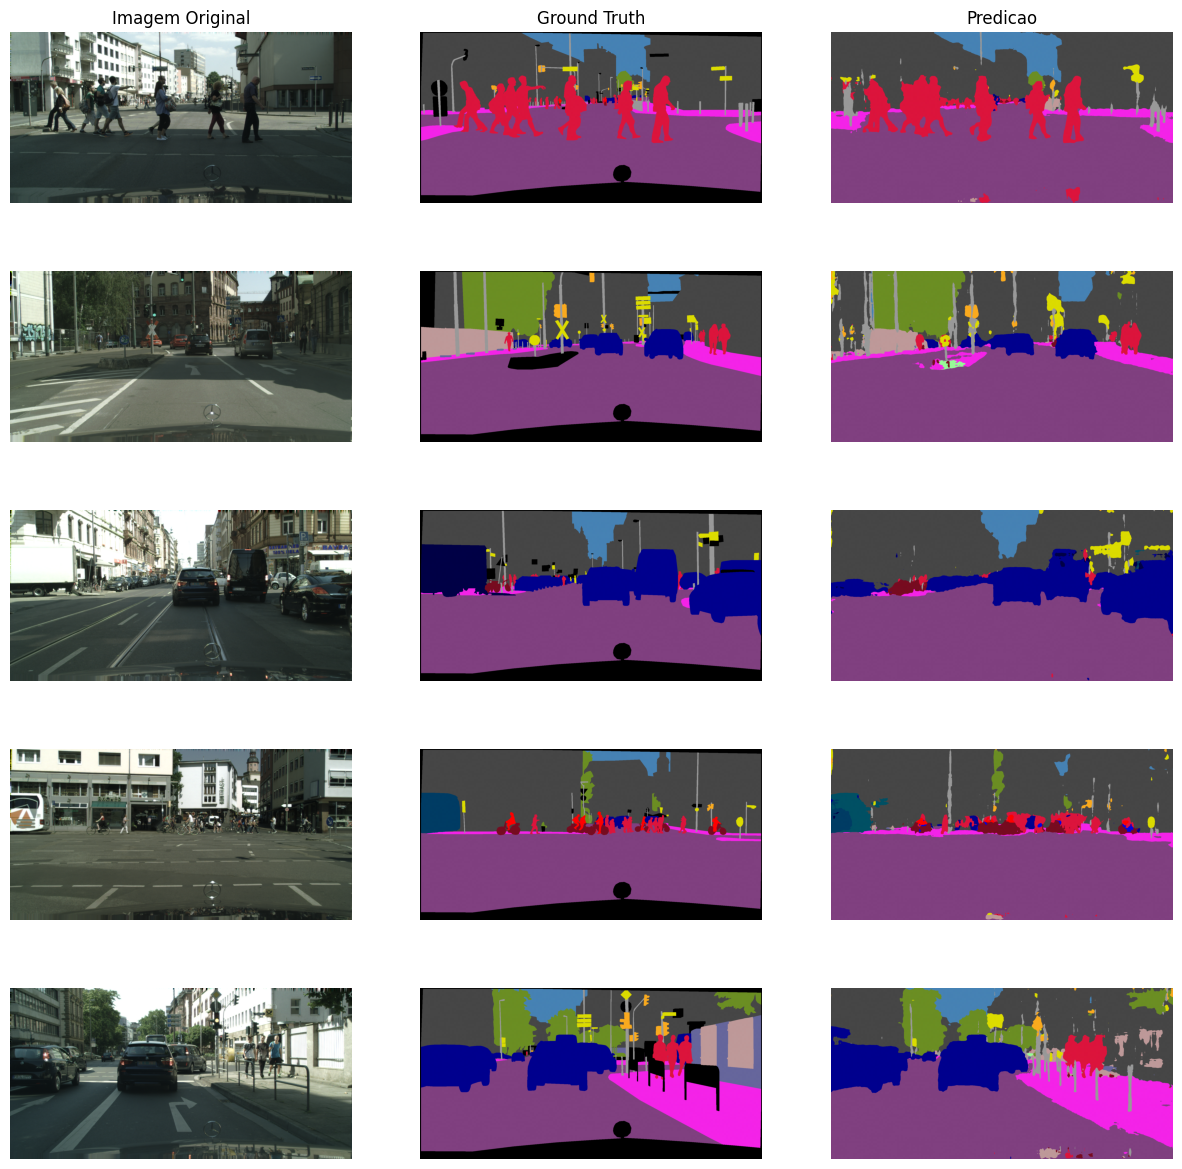

In [20]:
# Comparando mascaras verdadeirass com as mascaras preditas pelo modelo
dataset_show(val_dataset, n=5, predict_masks=True, model=loaded_model, device=device, cmap=cmap)

In [21]:
torch.cuda.empty_cache()